In [ ]:
from google.colab import drive
drive.mount('/content/drive',)

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [
    CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR,
    MODEL_DIR, GRAPH_DIR, REPORT_DIR,
    PRED_DIR, EXPLAIN_DIR, UNCERTAIN_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [ ]:
!pip install -q moviepy librosa soundfile opencv-python transformers sentence-transformers openai-whisper
!pip install -q spafe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import json
import os

metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

df = pd.DataFrame(metadata).T.reset_index()
df = df.rename(columns={"index": "filename"})

df["label"] = df["label"].str.upper()


df["label_num"] = df["label"].map({
    "REAL": 1,
    "FAKE": 0
})

df["video_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, x))

df = df[df["video_path"].apply(os.path.exists)]

print(df.head())
print(df["label"].value_counts())

         filename label  split        original  label_num  \
0  owxbbpjpch.mp4  FAKE  train  wynotylpnm.mp4          0   
1  vpmyeepbep.mp4  REAL  train             NaN          1   
2  fzvpbrzssi.mp4  REAL  train             NaN          1   
3  htorvhbcae.mp4  FAKE  train  wclvkepakb.mp4          0   
4  fckxaqjbxk.mp4  FAKE  train  vpmyeepbep.mp4          0   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  
label
FAKE    1248
REAL      86
Name: count, dtype: int64


In [ ]:
real_df = df[df["label"] == "REAL"]
fake_df = df[df["label"] == "FAKE"]

min_count = min(len(real_df), len(fake_df))

balanced_df = pd.concat([
    real_df.sample(min_count, random_state=42),
    fake_df.sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

balanced_csv_path = os.path.join(CSV_DIR, "balanced_metadata.csv")
balanced_df.to_csv(balanced_csv_path, index=False)

print("Balanced data saved:", balanced_csv_path)
print(balanced_df["label"].value_counts())

Balanced data saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/balanced_metadata.csv
label
REAL    86
FAKE    86
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df["label_num"]
)

train_csv = os.path.join(CSV_DIR, "train.csv")
test_csv = os.path.join(CSV_DIR, "test.csv")

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Train:", train_df["label"].value_counts())
print("Test:", test_df["label"].value_counts())

Train: label
REAL    69
FAKE    68
Name: count, dtype: int64
Test: label
FAKE    18
REAL    17
Name: count, dtype: int64


In [ ]:
import cv2
from tqdm import tqdm

def extract_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()


for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    save_dir = os.path.join(FRAMES_DIR, video_name)
    extract_frames(row["video_path"], save_dir)

100%|██████████| 172/172 [23:00<00:00,  8.02s/it]


In [ ]:
import shutil

VISUAL_DATASET_DIR = os.path.join(PROCESSED_DIR, "visual_dataset")

for split_name, split_df in [("train", train_df), ("test", test_df)]:
    for label in ["REAL", "FAKE"]:
        os.makedirs(os.path.join(VISUAL_DATASET_DIR, split_name, label), exist_ok=True)

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        video_name = row["filename"].replace(".mp4", "")
        src_dir = os.path.join(FRAMES_DIR, video_name)
        label = row["label"]

        if os.path.exists(src_dir):
            for frame_file in os.listdir(src_dir):
                src = os.path.join(src_dir, frame_file)
                dst = os.path.join(
                    VISUAL_DATASET_DIR,
                    split_name,
                    label,
                    video_name + "_" + frame_file
                )
                shutil.copy(src, dst)

100%|██████████| 35/35 [00:41<00:00,  1.18s/it]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(VISUAL_DATASET_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    os.path.join(VISUAL_DATASET_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(train_data.class_indices)

Found 685 images belonging to 2 classes.
Found 175 images belonging to 2 classes.
{'FAKE': 0, 'REAL': 1}


In [ ]:
def build_visual_model(base_model_name):
    if base_model_name == "mobilenet":
        base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_model_name == "resnet":
        base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
    elif base_model_name == "efficientnet":
        base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

   
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
visual_models = {}

for model_name in ["mobilenet", "resnet", "efficientnet"]:
    print("Training:", model_name)

    model = build_visual_model(model_name)

    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=EPOCHS
    )

    save_path = os.path.join(MODEL_DIR, f"{model_name}_visual_model.keras")
    model.save(save_path)

    visual_models[model_name] = model

    print("Saved:", save_path)

Training: mobilenet
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 829ms/step - accuracy: 0.5766 - loss: 0.7309 - val_accuracy: 0.5886 - val_loss: 0.6771
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - accuracy: 0.6394 - loss: 0.6515 - val_accuracy: 0.6743 - val_loss: 0.6116
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 36s 837ms/step - accuracy: 0.6292 - loss: 0.6365 - val_accuracy: 0.6343 - val_loss: 0.6423
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 722ms/step - accuracy: 0.6613 - loss: 0.6100 - val_accuracy: 0.7200 - val_loss: 0.6198
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 729ms/step - accuracy: 0.6540 - loss: 0.6194 - val_accuracy: 0.6171 - val_loss: 0.6591
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/mobilenet_visual_model.keras
Training: resnet
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.4949 - loss: 0.7800 - val_accuracy: 0.7429 - val_loss: 0.6682
E

In [ ]:
from moviepy.editor import VideoFileClip

def extract_audio(video_path, audio_path):
    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
        clip.close()
    except Exception as e:
        print("Audio error:", video_path, e)


for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    if not os.path.exists(audio_path):
        extract_audio(row["video_path"], audio_path)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

100%|██████████| 172/172 [00:01<00:00, 167.66it/s]


In [ ]:
import librosa
import numpy as np
from spafe.features.rplp import plp

def extract_mfcc(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    return np.mean(mfcc, axis=1)

def extract_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel)
    return np.mean(mel_db, axis=1)

def extract_plp(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    
    features = plp(y, fs=sr)
    return np.mean(features, axis=0)

In [ ]:
audio_rows = []

for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    if os.path.exists(audio_path):
        try:
            mfcc_feat = extract_mfcc(audio_path)
            mel_feat = extract_mel(audio_path)
            plp_feat = extract_plp(audio_path)

            audio_rows.append({
                "filename": row["filename"],
                "label_num": row["label_num"],
                "mfcc": mfcc_feat,
                "mel": mel_feat,
                "plp": plp_feat
            })

        except Exception as e:
            print("Feature error:", row["filename"], e)

audio_df = pd.DataFrame(audio_rows)
print(audio_df.head())

100%|██████████| 172/172 [02:47<00:00,  1.03it/s]

         filename  label_num  \
0  fufcmupzen.mp4          1   
1  muhgixhdmd.mp4          0   
2  haxnhfvqvs.mp4          0   
3  rmuxlgsedw.mp4          1   
4  yeouperxzc.mp4          0   

                                                mfcc  \
0  [-394.55457, 75.85335, 9.717398, 25.677856, -7...   
1  [-442.6298, 92.47945, 34.893433, 34.299088, 10...   
2  [-425.42142, 79.773384, 2.9187164, 17.939457, ...   
3  [-463.23273, 77.28458, 16.22161, 29.732967, -5...   
4  [-450.37082, 70.31432, 19.556286, 24.422426, -...   

                                                 mel  \
0  [-21.002556, -18.81882, -20.363007, -20.852863...   
1  [-20.225826, -18.281742, -13.825868, -13.95782...   
2  [-35.81922, -30.215036, -17.622816, -19.16235,...   
3  [-33.316242, -28.26538, -20.293835, -22.724043...   
4  [-31.15932, -28.43566, -18.371407, -19.483696,...   

                                                 plp  
0  [-86.45931901229937, -1.0075104481415704, -0.5...  
1  [-83.66402465953071,

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import joblib

def train_audio_model(feature_name, model, save_name):
    X = np.vstack(audio_df[feature_name].values)
    y = audio_df["label_num"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(save_name, "accuracy:", acc)

    path = os.path.join(MODEL_DIR, save_name)
    joblib.dump(model, path)

    return model

mfcc_model = train_audio_model(
    "mfcc",
    RandomForestClassifier(n_estimators=100, random_state=42),
    "mfcc_audio_model.pkl"
)

mel_model = train_audio_model(
    "mel",
    LogisticRegression(max_iter=1000),
    "mel_audio_model.pkl"
)

plp_model = train_audio_model(
    "plp",
    SVC(probability=True),
    "plp_audio_model.pkl"
)

mfcc_audio_model.pkl accuracy: 0.5142857142857142


STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



mel_audio_model.pkl accuracy: 0.5142857142857142
plp_audio_model.pkl accuracy: 0.4857142857142857


In [ ]:
import whisper

whisper_model = whisper.load_model("base")

def transcribe_audio(audio_path):
    try:
        result = whisper_model.transcribe(audio_path)
        return result["text"]
    except Exception as e:
        print("Transcription error:", e)
        return ""

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 124MiB/s]


In [ ]:
text_rows = []

for _, row in tqdm(balanced_df.iterrows(), total=len(balanced_df)):
    video_name = row["filename"].replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    if os.path.exists(transcript_path):
        with open(transcript_path, "r", encoding="utf-8") as f:
            transcript = f.read()
    else:
        transcript = transcribe_audio(audio_path)

        with open(transcript_path, "w", encoding="utf-8") as f:
            f.write(transcript)

    text_rows.append({
        "filename": row["filename"],
        "label_num": row["label_num"],
        "transcript": transcript
    })

text_df = pd.DataFrame(text_rows)
text_df.head()

100%|██████████| 172/172 [00:41<00:00,  4.12it/s]


,filename,label_num,transcript
0,fufcmupzen.mp4,1,Typically junk food is preparing our brains t...
1,muhgixhdmd.mp4,0,"Why do we need art? Well, we need art for so ..."
2,haxnhfvqvs.mp4,0,of times they will not get the proper attenti...
3,rmuxlgsedw.mp4,1,So I guess the point of that being we would p...
4,yeouperxzc.mp4,0,of what is important to us. So I do think tha...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import joblib

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    text_df["transcript"],
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

tfidf_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

tfidf_model.fit(X_train, y_train)

print("TF-IDF accuracy:", tfidf_model.score(X_test, y_test))

joblib.dump(tfidf_model, os.path.join(MODEL_DIR, "tfidf_text_model.pkl"))

TF-IDF accuracy: 0.45714285714285713


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/tfidf_text_model.pkl']

In [ ]:
bert_embedder = SentenceTransformer("bert-base-nli-mean-tokens")

bert_embeddings = bert_embedder.encode(
    text_df["transcript"].tolist(),
    show_progress_bar=True
)

X_train, X_test, y_train, y_test = train_test_split(
    bert_embeddings,
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

bert_clf = LogisticRegression(max_iter=1000)
bert_clf.fit(X_train, y_train)

print("BERT accuracy:", bert_clf.score(X_test, y_test))

joblib.dump(bert_clf, os.path.join(MODEL_DIR, "bert_text_model.pkl"))

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

BERT accuracy: 0.45714285714285713


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/bert_text_model.pkl']

In [ ]:
roberta_embedder = SentenceTransformer("sentence-transformers/all-roberta-large-v1")

roberta_embeddings = roberta_embedder.encode(
    text_df["transcript"].tolist(),
    show_progress_bar=True
)

X_train, X_test, y_train, y_test = train_test_split(
    roberta_embeddings,
    text_df["label_num"],
    test_size=0.2,
    random_state=42,
    stratify=text_df["label_num"]
)

roberta_clf = RandomForestClassifier(n_estimators=100, random_state=42)
roberta_clf.fit(X_train, y_train)

print("RoBERTa accuracy:", roberta_clf.score(X_test, y_test))

joblib.dump(roberta_clf, os.path.join(MODEL_DIR, "roberta_text_model.pkl"))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

RoBERTa accuracy: 0.5428571428571428


['/content/drive/MyDrive/Deepfake_Project/data/outputs/models/roberta_text_model.pkl']

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_visual_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224,224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        model_scores = []

        for model_name, model in visual_models.items():
            score = model.predict(img_arr, verbose=0)[0][0]
            model_scores.append(score)

        frame_scores.append(np.mean(model_scores))

    visual_score = np.mean(frame_scores)

    return float(visual_score)

In [ ]:
def predict_audio_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)
    plp_feat = extract_plp(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]
    plp_score = plp_model.predict_proba(plp_feat)[0][1]

    audio_score = np.mean([
        mfcc_score,
        mel_score,
        plp_score
    ])

    return float(audio_score)

In [ ]:
def predict_text_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    with open(transcript_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    text_score = np.mean([
        tfidf_score,
        bert_score,
        roberta_score
    ])

    return float(text_score)

In [ ]:
def classify_final_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
def generate_verdict_explanation(visual_score, audio_score, text_score, final_score, predicted_label):
    explanation = (
        f"The visual score is {visual_score:.4f}, audio score is {audio_score:.4f}, "
        f"and text score is {text_score:.4f}. The final multimodal average score is "
        f"{final_score:.4f}. Since the score is classified as {predicted_label}, "
    )

    if predicted_label == "REAL":
        explanation += "the video is predicted as real because the final score is closer to the REAL class."
    elif predicted_label == "FAKE":
        explanation += "the video is predicted as fake because the final score is closer to the FAKE class."
    else:
        explanation += "the video is marked uncertain because the score lies in the middle confidence range."

    return explanation

In [ ]:
final_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        final_score = np.mean([
            visual_score,
            audio_score,
            text_score
        ])

        predicted_label = classify_final_score(final_score)

        verdict = "Correct" if predicted_label == true_label else "Incorrect"

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"

        explanation = generate_verdict_explanation(
            visual_score,
            audio_score,
            text_score,
            final_score,
            predicted_label
        )

        final_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "final_score": final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

final_df = pd.DataFrame(final_results)

final_csv_path = os.path.join(PRED_DIR, "final_multimodal_predictions.csv")
final_df.to_csv(final_csv_path, index=False)

print("Saved:", final_csv_path)
final_df.head()

100%|██████████| 35/35 [02:36<00:00,  4.48s/it]


Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_multimodal_predictions.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.552313,0.314300,0.249812,0.372142,REAL,FAKE,Incorrect,"The visual score is 0.5523, audio score is 0.3..."
1,haxnhfvqvs.mp4,0.537759,0.593128,0.764832,0.631906,FAKE,REAL,Incorrect,"The visual score is 0.5378, audio score is 0.5..."
2,yeouperxzc.mp4,0.555852,0.739063,0.803122,0.699346,FAKE,REAL,Incorrect,"The visual score is 0.5559, audio score is 0.7..."
3,qloyrbpobv.mp4,0.520437,0.373572,0.496245,0.463418,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.5204, audio score is 0.3..."
4,qarqtkvgby.mp4,0.457136,0.385238,0.298813,0.380396,REAL,FAKE,Incorrect,"The visual score is 0.4571, audio score is 0.3..."


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def save_gradcam(frame_path, model, save_path, last_conv_layer_name="Conv_1"):
    img = image.load_img(frame_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    original_img = cv2.imread(frame_path)
    original_img = cv2.resize(original_img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    cv2.imwrite(save_path, superimposed_img)

    return save_path

In [ ]:
gradcam_paths = []

mobilenet_model = visual_models["mobilenet"]

for _, row in tqdm(final_df.iterrows(), total=len(final_df)):
    filename = row["filename"]
    video_name = filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    try:
        first_frame = os.listdir(frame_dir)[0]
        frame_path = os.path.join(frame_dir, first_frame)

        save_path = os.path.join(EXPLAIN_DIR, video_name + "_gradcam.jpg")

        gradcam_path = save_gradcam(
            frame_path,
            mobilenet_model,
            save_path,
            last_conv_layer_name="Conv_1"
        )

        gradcam_paths.append(gradcam_path)

    except Exception as e:
        print("Grad-CAM error:", filename, e)
        gradcam_paths.append("Not generated")

final_df["gradcam_image_path"] = gradcam_paths

final_csv_with_gradcam = os.path.join(PRED_DIR, "final_predictions_with_gradcam.csv")
final_df.to_csv(final_csv_with_gradcam, index=False)

print("Saved:", final_csv_with_gradcam)
final_df.head()

  0%|          | 0/35 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)

100%|██████████| 35/35 [00:28<00:00,  1.21it/s]


Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/final_predictions_with_gradcam.csv


,filename,visual_score,audio_score,text_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,dhjnjkzuhq.mp4,0.552313,0.314300,0.249812,0.372142,REAL,FAKE,Incorrect,"The visual score is 0.5523, audio score is 0.3...",/content/drive/MyDrive/Deepfake_Project/data/o...
1,haxnhfvqvs.mp4,0.537759,0.593128,0.764832,0.631906,FAKE,REAL,Incorrect,"The visual score is 0.5378, audio score is 0.5...",/content/drive/MyDrive/Deepfake_Project/data/o...
2,yeouperxzc.mp4,0.555852,0.739063,0.803122,0.699346,FAKE,REAL,Incorrect,"The visual score is 0.5559, audio score is 0.7...",/content/drive/MyDrive/Deepfake_Project/data/o...
3,qloyrbpobv.mp4,0.520437,0.373572,0.496245,0.463418,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.5204, audio score is 0.3...",/content/drive/MyDrive/Deepfake_Project/data/o...
4,qarqtkvgby.mp4,0.457136,0.385238,0.298813,0.380396,REAL,FAKE,Incorrect,"The visual score is 0.4571, audio score is 0.3...",/content/drive/MyDrive/Deepfake_Project/data/o...


Model Evaluation Results
------------------------
Accuracy : 0.4545
Precision: 0.5714
Recall   : 0.3077
F1 Score : 0.4

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.40      0.67      0.50         9
        REAL       0.57      0.31      0.40        13

    accuracy                           0.45        22
   macro avg       0.49      0.49      0.45        22
weighted avg       0.50      0.45      0.44        22



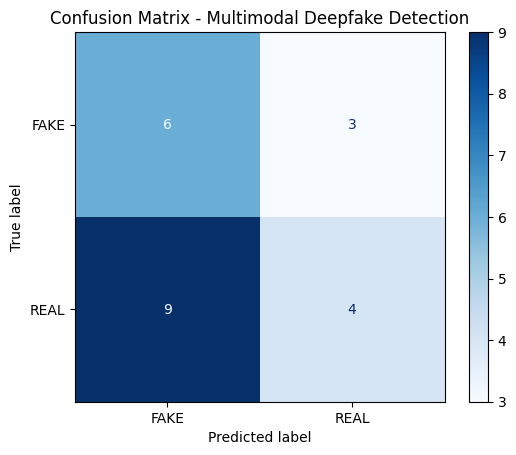

Confusion matrix saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix.png


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os


eval_df = final_df[final_df["predicted_label"] != "UNCERTAIN"].copy()

y_true = eval_df["true_label"]
y_pred = eval_df["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="REAL")
recall = recall_score(y_true, y_pred, pos_label="REAL")
f1 = f1_score(y_true, y_pred, pos_label="REAL")

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))


cm = confusion_matrix(y_true, y_pred, labels=["FAKE", "REAL"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Multimodal Deepfake Detection")

conf_matrix_path = os.path.join(GRAPH_DIR, "confusion_matrix.png")
plt.savefig(conf_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", conf_matrix_path)

In [ ]:
counts = final_df["predicted_label"].value_counts()

real_count = counts.get("REAL", 0)
fake_count = counts.get("FAKE", 0)
uncertain_count = counts.get("UNCERTAIN", 0)

print("Total Predictions:")
print("REAL      :", real_count)
print("FAKE      :", fake_count)
print("UNCERTAIN :", uncertain_count)

Total Predictions:
REAL      : 7
FAKE      : 15
UNCERTAIN : 13


In [ ]:
summary_df = final_df["predicted_label"].value_counts().reset_index()
summary_df.columns = ["Label", "Count"]

print(summary_df)

       Label  Count
0       FAKE     15
1  UNCERTAIN     13
2       REAL      7


In [ ]:
print("\nSoft Voting (Simple Average) Evaluation:")
print("--------------------------------------")

eval_df = final_df[final_df["predicted_label"] != "UNCERTAIN"].copy()
y_true_soft = eval_df["true_label"]
y_pred_soft = eval_df["predicted_label"]

accuracy_soft_voting = accuracy_score(y_true_soft, y_pred_soft)
print("Accuracy :", accuracy_soft_voting)


Soft Voting (Simple Average) Evaluation:
--------------------------------------
Accuracy : 0.45454545454545453


In [ ]:
print("\nTrue Label Counts:")
print(final_df["true_label"].value_counts())


True Label Counts:
true_label
FAKE    18
REAL    17
Name: count, dtype: int64


In [ ]:


def weighted_fusion_score(visual_score, audio_score, text_score,
                          visual_weight=0.50,
                          audio_weight=0.25,
                          text_weight=0.25):

    final_weighted_score = (
        visual_score * visual_weight +
        audio_score * audio_weight +
        text_score * text_weight
    )

    return final_weighted_score

In [ ]:
def classify_weighted_score(weighted_score):
    if weighted_score >= 0.60:
        return "REAL"
    elif weighted_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
visual_score = predict_visual_score(filename)
audio_score = predict_audio_score(filename)
text_score = predict_text_score(filename)

weighted_final_score = weighted_fusion_score(
    visual_score,
    audio_score,
    text_score,
    visual_weight=0.50,
    audio_weight=0.25,
    text_weight=0.25
)

predicted_label = classify_weighted_score(weighted_final_score)

In [ ]:
weighted_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        weighted_final_score = weighted_fusion_score(
            visual_score,
            audio_score,
            text_score,
            visual_weight=0.50,
            audio_weight=0.25,
            text_weight=0.25
        )

        predicted_label = classify_weighted_score(weighted_final_score)

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif predicted_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"The visual score is {visual_score:.4f}, audio score is {audio_score:.4f}, "
            f"and text score is {text_score:.4f}. The weighted final score is "
            f"{weighted_final_score:.4f}. The model gives more importance to visual "
            f"features because deepfake manipulation usually appears strongly in facial "
            f"regions. Based on the weighted score, the video is classified as "
            f"{predicted_label}."
        )

        weighted_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "weighted_final_score": weighted_final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

weighted_final_df = pd.DataFrame(weighted_results)

weighted_csv_path = os.path.join(PRED_DIR, "weighted_multimodal_predictions.csv")
weighted_final_df.to_csv(weighted_csv_path, index=False)

print("Saved:", weighted_csv_path)
weighted_final_df.head()

100%|██████████| 35/35 [02:48<00:00,  4.82s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/weighted_multimodal_predictions.csv


,filename,visual_score,audio_score,text_score,weighted_final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.552313,0.314300,0.249812,0.417184,REAL,UNCERTAIN,Needs Human Review,"The visual score is 0.5523, audio score is 0.3..."
1,haxnhfvqvs.mp4,0.537759,0.593128,0.764832,0.608370,FAKE,REAL,Incorrect,"The visual score is 0.5378, audio score is 0.5..."
2,yeouperxzc.mp4,0.555852,0.739063,0.803122,0.663472,FAKE,REAL,Incorrect,"The visual score is 0.5559, audio score is 0.7..."
3,qloyrbpobv.mp4,0.520437,0.373572,0.496245,0.477673,FAKE,UNCERTAIN,Needs Human Review,"The visual score is 0.5204, audio score is 0.3..."
4,qarqtkvgby.mp4,0.457136,0.385238,0.298813,0.399581,REAL,FAKE,Incorrect,"The visual score is 0.4571, audio score is 0.3..."


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_weighted_df = weighted_final_df[
    weighted_final_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_weighted_df["true_label"]
y_pred = eval_weighted_df["predicted_label"]

print("Weighted Voting Evaluation")
print("--------------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Weighted Voting Evaluation
--------------------------
Accuracy : 0.47368421052631576
Precision: 0.5714285714285714
Recall   : 0.36363636363636365
F1 Score : 0.4444444444444444

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.42      0.62      0.50         8
        REAL       0.57      0.36      0.44        11

    accuracy                           0.47        19
   macro avg       0.49      0.49      0.47        19
weighted avg       0.51      0.47      0.47        19



In [ ]:
print("\nWeighted Voting Evaluation:")
print("--------------------------")

eval_weighted_df = weighted_final_df[
    weighted_final_df["predicted_label"] != "UNCERTAIN"
].copy()
y_true_weighted = eval_weighted_df["true_label"]
y_pred_weighted = eval_weighted_df["predicted_label"]

accuracy_weighted_voting = accuracy_score(y_true_weighted, y_pred_weighted)
print("Accuracy :", accuracy_weighted_voting)


Weighted Voting Evaluation:
--------------------------
Accuracy : 0.47368421052631576


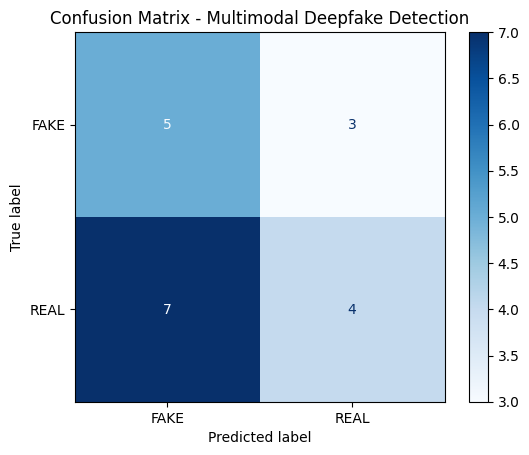

Confusion matrix saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/confusion_matrix.png


In [ ]:

cm = confusion_matrix(y_true, y_pred, labels=["FAKE", "REAL"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Multimodal Deepfake Detection")

conf_matrix_path = os.path.join(GRAPH_DIR, "confusion_matrix.png")
plt.savefig(conf_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", conf_matrix_path)

In [ ]:
def score_to_label(score):
    if score >= 0.60:
        return "REAL"
    elif score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
from collections import Counter

def hard_voting_label(visual_score, audio_score, text_score):
    visual_label = score_to_label(visual_score)
    audio_label = score_to_label(audio_score)
    text_label = score_to_label(text_score)

    votes = [visual_label, audio_label, text_label]
    vote_count = Counter(votes)

 
    most_common = vote_count.most_common()

   
    if most_common[0][1] >= 2:
        final_label = most_common[0][0]
    else:
        final_label = "UNCERTAIN"

    return final_label, visual_label, audio_label, text_label

In [ ]:
hard_voting_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_score(filename)
        audio_score = predict_audio_score(filename)
        text_score = predict_text_score(filename)

        final_label, visual_label, audio_label, text_label = hard_voting_label(
            visual_score,
            audio_score,
            text_score
        )

        if final_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif final_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"Visual modality voted as {visual_label}, audio modality voted as {audio_label}, "
            f"and text modality voted as {text_label}. Based on majority hard voting, "
            f"the final predicted label is {final_label}."
        )

        hard_voting_results.append({
            "filename": filename,
            "visual_score": visual_score,
            "audio_score": audio_score,
            "text_score": text_score,
            "visual_vote": visual_label,
            "audio_vote": audio_label,
            "text_vote": text_label,
            "true_label": true_label,
            "predicted_label": final_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

hard_voting_df = pd.DataFrame(hard_voting_results)

hard_voting_csv_path = os.path.join(PRED_DIR, "hard_voting_predictions.csv")
hard_voting_df.to_csv(hard_voting_csv_path, index=False)

print("Saved:", hard_voting_csv_path)
hard_voting_df.head()

100%|██████████| 35/35 [02:54<00:00,  4.97s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/hard_voting_predictions.csv


,filename,visual_score,audio_score,text_score,visual_vote,audio_vote,text_vote,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.552313,0.314300,0.249812,UNCERTAIN,FAKE,FAKE,REAL,FAKE,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."
1,haxnhfvqvs.mp4,0.537759,0.593128,0.764832,UNCERTAIN,UNCERTAIN,REAL,FAKE,UNCERTAIN,Needs Human Review,"Visual modality voted as UNCERTAIN, audio moda..."
2,yeouperxzc.mp4,0.555852,0.739063,0.803122,UNCERTAIN,REAL,REAL,FAKE,REAL,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."
3,qloyrbpobv.mp4,0.520437,0.373572,0.496245,UNCERTAIN,FAKE,UNCERTAIN,FAKE,UNCERTAIN,Needs Human Review,"Visual modality voted as UNCERTAIN, audio moda..."
4,qarqtkvgby.mp4,0.457136,0.385238,0.298813,UNCERTAIN,FAKE,FAKE,REAL,FAKE,Incorrect,"Visual modality voted as UNCERTAIN, audio moda..."


In [ ]:
print(hard_voting_df["predicted_label"].value_counts())

predicted_label
FAKE         17
UNCERTAIN    13
REAL          5
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_hard_df = hard_voting_df[
    hard_voting_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_hard_df["true_label"]
y_pred = eval_hard_df["predicted_label"]

print("Hard Voting Evaluation")
print("----------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Hard Voting Evaluation
----------------------
Accuracy : 0.45454545454545453
Precision: 0.6
Recall   : 0.23076923076923078
F1 Score : 0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.41      0.78      0.54         9
        REAL       0.60      0.23      0.33        13

    accuracy                           0.45        22
   macro avg       0.51      0.50      0.44        22
weighted avg       0.52      0.45      0.42        22



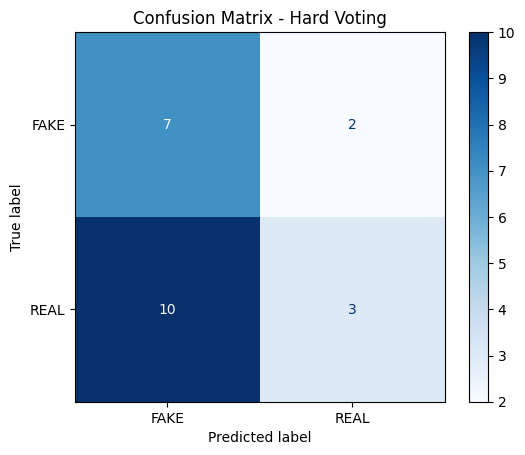

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["FAKE", "REAL"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Hard Voting")
plt.show()

In [ ]:
def classify_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"

In [ ]:
def predict_visual_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    frame_dir = os.path.join(FRAMES_DIR, video_name)

    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    visual_score = np.mean(all_frame_scores)

    return float(visual_score)

In [ ]:
def predict_audio_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    audio_path = os.path.join(AUDIO_DIR, video_name + ".wav")

    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)
    plp_feat = extract_plp(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]
    plp_score = plp_model.predict_proba(plp_feat)[0][1]

    audio_score = max(
        mfcc_score,
        mel_score,
        plp_score
    )

    return float(audio_score)

In [ ]:
def predict_text_max_score(video_filename):
    video_name = video_filename.replace(".mp4", "")
    transcript_path = os.path.join(TEXT_DIR, video_name + ".txt")

    with open(transcript_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    text_score = max(
        tfidf_score,
        bert_score,
        roberta_score
    )

    return float(text_score)

In [ ]:
max_fusion_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    filename = row["filename"]
    true_label = row["label"]

    try:
        visual_score = predict_visual_max_score(filename)
        audio_score = predict_audio_max_score(filename)
        text_score = predict_text_max_score(filename)

        final_score = np.mean([
            visual_score,
            audio_score,
            text_score
        ])

        predicted_label = classify_score(final_score)

        if predicted_label == "UNCERTAIN":
            verdict = "Needs Human Review"
        elif predicted_label == true_label:
            verdict = "Correct"
        else:
            verdict = "Incorrect"

        explanation = (
            f"The maximum score from visual models is {visual_score:.4f}, "
            f"the maximum score from audio models is {audio_score:.4f}, "
            f"and the maximum score from text models is {text_score:.4f}. "
            f"The final score is calculated by averaging these three max scores. "
            f"The final score is {final_score:.4f}, so the prediction is {predicted_label}."
        )

        max_fusion_results.append({
            "filename": filename,
            "visual_max_score": visual_score,
            "audio_max_score": audio_score,
            "text_max_score": text_score,
            "final_score": final_score,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "verdict": verdict,
            "explanation": explanation
        })

    except Exception as e:
        print("Prediction error:", filename, e)

max_fusion_df = pd.DataFrame(max_fusion_results)

max_fusion_csv_path = os.path.join(PRED_DIR, "max_fusion_predictions.csv")
max_fusion_df.to_csv(max_fusion_csv_path, index=False)

print("Saved:", max_fusion_csv_path)
max_fusion_df.head()

100%|██████████| 35/35 [02:55<00:00,  5.02s/it]

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/max_fusion_predictions.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,dhjnjkzuhq.mp4,0.588922,0.483652,0.483914,0.518829,REAL,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.5889...
1,haxnhfvqvs.mp4,0.578720,0.885000,0.887207,0.783642,FAKE,REAL,Incorrect,The maximum score from visual models is 0.5787...
2,yeouperxzc.mp4,0.608732,0.887012,0.969548,0.821764,FAKE,REAL,Incorrect,The maximum score from visual models is 0.6087...
3,qloyrbpobv.mp4,0.593365,0.483077,0.530076,0.535506,FAKE,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.5934...
4,qarqtkvgby.mp4,0.576204,0.483713,0.393338,0.484418,REAL,UNCERTAIN,Needs Human Review,The maximum score from visual models is 0.5762...


In [ ]:
print(max_fusion_df["predicted_label"].value_counts())

predicted_label
UNCERTAIN    25
REAL         10
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

eval_max_df = max_fusion_df[
    max_fusion_df["predicted_label"] != "UNCERTAIN"
].copy()

y_true = eval_max_df["true_label"]
y_pred = eval_max_df["predicted_label"]

print("Max Fusion Evaluation")
print("---------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="REAL"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="REAL"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="REAL"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Max Fusion Evaluation
---------------------
Accuracy : 0.7
Precision: 0.7
Recall   : 1.0
F1 Score : 0.8235294117647058

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.00      0.00      0.00         3
        REAL       0.70      1.00      0.82         7

    accuracy                           0.70        10
   macro avg       0.35      0.50      0.41        10
weighted avg       0.49      0.70      0.58        10



In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from tensorflow.keras.preprocessing import image
from scipy.linalg import LinAlgError 

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/trump.mp4"

external_filename = os.path.basename(EXTERNAL_VIDEO_PATH)
external_name = external_filename.replace(".mp4", "")

external_frame_dir = os.path.join(FRAMES_DIR, external_name)
external_audio_path = os.path.join(AUDIO_DIR, external_name + ".wav")
external_text_path = os.path.join(TEXT_DIR, external_name + ".txt")

os.makedirs(external_frame_dir, exist_ok=True)




def extract_external_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read video frames.")

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()

    return saved



def extract_external_audio(video_path, audio_path):
    clip = VideoFileClip(video_path)

    if clip.audio is None:
        clip.close()
        raise ValueError("No audio found in this video.")

    clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
    clip.close()

    return audio_path



def transcribe_external_audio(audio_path, text_path):
    transcript = transcribe_audio(audio_path)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript



def predict_external_visual_max_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    return float(np.mean(all_frame_scores))


def predict_external_audio_max_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5 
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e: 
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(max(mfcc_score, mel_score, plp_score))



def predict_external_text_max_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(max(tfidf_score, bert_score, roberta_score))




def classify_external_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"



print("Processing external video:", EXTERNAL_VIDEO_PATH)

frames_saved = extract_external_frames(
    EXTERNAL_VIDEO_PATH,
    external_frame_dir,
    frame_count=5
)

print("Frames extracted:", frames_saved)

extract_external_audio(
    EXTERNAL_VIDEO_PATH,
    external_audio_path
)

print("Audio extracted:", external_audio_path)

transcript = transcribe_external_audio(
    external_audio_path,
    external_text_path
)

print("Transcript saved:", external_text_path)

visual_max_score = predict_external_visual_max_score(external_frame_dir)
audio_max_score = predict_external_audio_max_score(external_audio_path)
text_max_score = predict_external_text_max_score(external_text_path)

final_score = np.mean([
    visual_max_score,
    audio_max_score,
    text_max_score
])

predicted_label = classify_external_score(final_score)

if predicted_label == "UNCERTAIN":
    verdict = "Needs Human Review"
elif predicted_label == "REAL":
    verdict = "Predicted as Real Video"
else:
    verdict = "Predicted as Fake Video"

explanation = (
    f"For this external video, the maximum visual score is {visual_max_score:.4f}, "
    f"maximum audio score is {audio_max_score:.4f}, and maximum text score is {text_max_score:.4f}. "
    f"The final score is calculated by averaging these three maximum modality scores. "
    f"The final score is {final_score:.4f}. Therefore, the video is classified as {predicted_label}."
)

external_result = {
    "filename": external_filename,
    "visual_max_score": visual_max_score,
    "audio_max_score": audio_max_score,
    "text_max_score": text_max_score,
    "final_score": final_score,
    "true_label": "Unknown",
    "predicted_label": predicted_label,
    "verdict": verdict,
    "explanation": explanation
}

external_result_df = pd.DataFrame([external_result])

external_csv_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction.csv"
)

external_result_df.to_csv(external_csv_path, index=False)

print("Saved:", external_csv_path)
external_result_df

Processing external video: /content/drive/MyDrive/trump.mp4
Frames extracted: 5


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/trump.txt
LinAlgError during PLP extraction for /content/drive/MyDrive/Deepfake_Project/data/processed/audio/trump.wav: singular matrix. Using neutral PLP score (0.5).
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,trump.mp4,0.748134,0.96648,0.977677,0.89743,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path = "Not generated"

try:
   
    mobilenet_model = visual_models["mobilenet"]

    
    first_external_frame = os.listdir(external_frame_dir)[0]
    external_frame_path = os.path.join(external_frame_dir, first_external_frame)

    
    external_gradcam_save_path = os.path.join(EXPLAIN_DIR, external_name + "_gradcam.jpg")

   
    external_gradcam_path = save_gradcam(
        external_frame_path,
        mobilenet_model,
        external_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)


external_result_df["gradcam_image_path"] = external_gradcam_path


external_csv_with_gradcam_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction_with_gradcam.csv"
)
external_result_df.to_csv(external_csv_with_gradcam_path, index=False)

print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path)
display(external_result_df)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/trump_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,trump.mp4,0.748134,0.96648,0.977677,0.89743,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


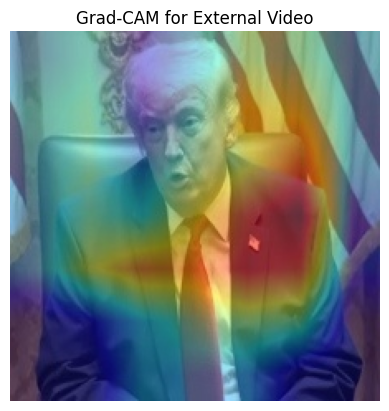

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if external_gradcam_path != "Not generated" and os.path.exists(external_gradcam_path):
    img = mpimg.imread(external_gradcam_path)
    plt.imshow(img)
    plt.axis('off') 
    plt.title('Grad-CAM for External Video')
    plt.show()
else:
    print("Grad-CAM image not found or not generated.")

In [ ]:
target_video_filename_uncertain_fake = 'qloyrbpobv.mp4'
EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE = os.path.join(RAW_DIR, target_video_filename_uncertain_fake)

external_filename_uncertain_fake = os.path.basename(EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE)
external_name_uncertain_fake = external_filename_uncertain_fake.replace(".mp4", "")

external_frame_dir_uncertain_fake = os.path.join(FRAMES_DIR, external_name_uncertain_fake)
external_audio_path_uncertain_fake = os.path.join(AUDIO_DIR, external_name_uncertain_fake + ".wav")
external_text_path_uncertain_fake = os.path.join(TEXT_DIR, external_name_uncertain_fake + ".txt")

os.makedirs(external_frame_dir_uncertain_fake, exist_ok=True)

print("Processing external video:", EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE)

try:
    frames_saved_uncertain_fake = extract_external_frames(
        EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE,
        external_frame_dir_uncertain_fake,
        frame_count=5
    )
    print("Frames extracted:", frames_saved_uncertain_fake)

    extract_external_audio(
        EXTERNAL_VIDEO_PATH_UNCERTAIN_FAKE,
        external_audio_path_uncertain_fake
    )
    print("Audio extracted:", external_audio_path_uncertain_fake)

    transcript_uncertain_fake = transcribe_external_audio(
        external_audio_path_uncertain_fake,
        external_text_path_uncertain_fake
    )
    print("Transcript saved:", external_text_path_uncertain_fake)

   
    visual_max_score_uncertain_fake = predict_external_visual_max_score(external_frame_dir_uncertain_fake)
    audio_max_score_uncertain_fake = predict_external_audio_max_score(external_audio_path_uncertain_fake)
    text_max_score_uncertain_fake = predict_external_text_max_score(external_text_path_uncertain_fake)

    final_score_uncertain_fake = np.mean([
        visual_max_score_uncertain_fake,
        audio_max_score_uncertain_fake,
        text_max_score_uncertain_fake
    ])

    predicted_label_uncertain_fake = classify_external_score(final_score_uncertain_fake)

    if predicted_label_uncertain_fake == "UNCERTAIN":
        verdict_uncertain_fake = "Needs Human Review"
    elif predicted_label_uncertain_fake == "REAL":
        verdict_uncertain_fake = "Predicted as Real Video"
    else:
        verdict_uncertain_fake = "Predicted as Fake Video"

    explanation_uncertain_fake = (
        f"For this external video, the maximum visual score is {visual_max_score_uncertain_fake:.4f}, "
        f"maximum audio score is {audio_max_score_uncertain_fake:.4f}, and maximum text score is {text_max_score_uncertain_fake:.4f}. "
        f"The final score is calculated by averaging these three maximum modality scores. "
        f"The final score is {final_score_uncertain_fake:.4f}. Therefore, the video is classified as {predicted_label_uncertain_fake}."
    )

    external_result_uncertain_fake = {
        "filename": external_filename_uncertain_fake,
        "visual_max_score": visual_max_score_uncertain_fake,
        "audio_max_score": audio_max_score_uncertain_fake,
        "text_max_score": text_max_score_uncertain_fake,
        "final_score": final_score_uncertain_fake,
        "true_label": "FAKE", 
        "predicted_label": predicted_label_uncertain_fake,
        "verdict": verdict_uncertain_fake,
        "explanation": explanation_uncertain_fake
    }

    external_result_df_uncertain_fake = pd.DataFrame([external_result_uncertain_fake])

    external_csv_path_uncertain_fake = os.path.join(
        PRED_DIR,
        "external_video_max_fusion_prediction_uncertain_fake.csv"
    )

    external_result_df_uncertain_fake.to_csv(external_csv_path_uncertain_fake, index=False)

    print("Saved:", external_csv_path_uncertain_fake)
    display(external_result_df_uncertain_fake)

except Exception as e:
    print(f"An error occurred during processing: {e}")

Processing external video: /content/drive/MyDrive/Deepfake_Project/data/raw/dfdc_train_part_00/qloyrbpobv.mp4
Frames extracted: 5


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/qloyrbpobv.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/qloyrbpobv.txt
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_uncertain_fake.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,qloyrbpobv.mp4,0.593365,0.48344,0.530076,0.535627,FAKE,UNCERTAIN,Needs Human Review,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path_uncertain_fake = "Not generated"

try:
   
    mobilenet_model = visual_models["mobilenet"]

   
    first_external_frame_uncertain_fake = os.listdir(external_frame_dir_uncertain_fake)[0]
    external_frame_path_uncertain_fake = os.path.join(external_frame_dir_uncertain_fake, first_external_frame_uncertain_fake)

    
    external_gradcam_save_path_uncertain_fake = os.path.join(EXPLAIN_DIR, external_name_uncertain_fake + "_gradcam.jpg")

   
    external_gradcam_path_uncertain_fake = save_gradcam(
        external_frame_path_uncertain_fake,
        mobilenet_model,
        external_gradcam_save_path_uncertain_fake,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path_uncertain_fake)

except Exception as e:
    print("Grad-CAM error for external video:", e)


if 'external_result_df_uncertain_fake' in locals():
    external_result_df_uncertain_fake["gradcam_image_path"] = external_gradcam_path_uncertain_fake

    
    external_csv_with_gradcam_path_uncertain_fake = os.path.join(
        PRED_DIR,
        "external_video_max_fusion_prediction_uncertain_fake_with_gradcam.csv"
    )
    external_result_df_uncertain_fake.to_csv(external_csv_with_gradcam_path_uncertain_fake, index=False)

    print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path_uncertain_fake)
    display(external_result_df_uncertain_fake)
else:
    print("external_result_df_uncertain_fake not found, cannot add gradcam_image_path.")

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/qloyrbpobv_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_uncertain_fake_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,qloyrbpobv.mp4,0.593365,0.48344,0.530076,0.535627,FAKE,UNCERTAIN,Needs Human Review,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


Displaying Grad-CAM for the uncertain fake video:


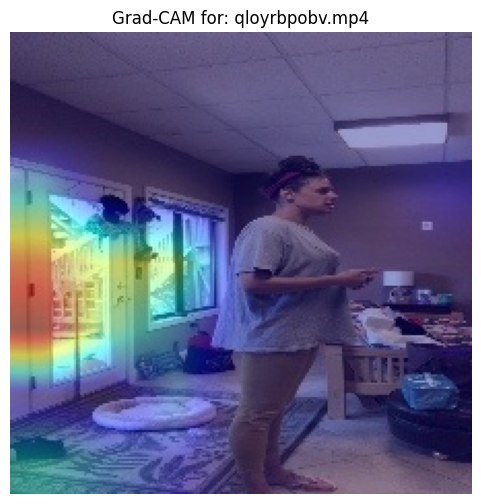

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

if 'external_gradcam_path_uncertain_fake' in locals() and os.path.exists(external_gradcam_path_uncertain_fake):
    print("Displaying Grad-CAM for the uncertain fake video:")
    img = mpimg.imread(external_gradcam_path_uncertain_fake)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.title(f'Grad-CAM for: {external_name_uncertain_fake}.mp4')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the uncertain fake video.")

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from moviepy.editor import VideoFileClip
from tensorflow.keras.preprocessing import image
from scipy.linalg import LinAlgError 

EXTERNAL_VIDEO_PATH = "/content/drive/MyDrive/my.mp4"

external_filename = os.path.basename(EXTERNAL_VIDEO_PATH)
external_name = external_filename.replace(".mp4", "")

external_frame_dir = os.path.join(FRAMES_DIR, external_name)
external_audio_path = os.path.join(AUDIO_DIR, external_name + ".wav")
external_text_path = os.path.join(TEXT_DIR, external_name + ".txt")

os.makedirs(external_frame_dir, exist_ok=True)




def extract_external_frames(video_path, save_dir, frame_count=5):
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}. Check if the path is correct and the video format is supported.")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read video frames.")

    frame_indices = [
        int(i * total_frames / frame_count)
        for i in range(frame_count)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (224, 224))
            frame_path = os.path.join(save_dir, f"frame_{saved}.jpg")
            cv2.imwrite(frame_path, frame)
            saved += 1

    cap.release()

    return saved




def extract_external_audio(video_path, audio_path):
    clip = VideoFileClip(video_path)

    if clip.audio is None:
        clip.close()
        raise ValueError("No audio found in this video.")

    clip.audio.write_audiofile(audio_path, verbose=False, logger=None)
    clip.close()

    return audio_path




def transcribe_external_audio(audio_path, text_path):
    transcript = transcribe_audio(audio_path)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(transcript)

    return transcript




def predict_external_visual_max_score(frame_dir):
    all_frame_scores = []

    for frame_file in os.listdir(frame_dir):
        frame_path = os.path.join(frame_dir, frame_file)

        img = image.load_img(frame_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        mobilenet_score = visual_models["mobilenet"].predict(img_arr, verbose=0)[0][0]
        resnet_score = visual_models["resnet"].predict(img_arr, verbose=0)[0][0]
        efficientnet_score = visual_models["efficientnet"].predict(img_arr, verbose=0)[0][0]

        frame_max_score = max(
            mobilenet_score,
            resnet_score,
            efficientnet_score
        )

        all_frame_scores.append(frame_max_score)

    return float(np.mean(all_frame_scores))




def predict_external_audio_max_score(audio_path):
    mfcc_feat = extract_mfcc(audio_path).reshape(1, -1)
    mel_feat = extract_mel(audio_path).reshape(1, -1)

    mfcc_score = mfcc_model.predict_proba(mfcc_feat)[0][1]
    mel_score = mel_model.predict_proba(mel_feat)[0][1]

    plp_score = 0.5  
    try:
        plp_feat = extract_plp(audio_path).reshape(1, -1)
        plp_score = plp_model.predict_proba(plp_feat)[0][1]
    except LinAlgError as e:
        print(f"LinAlgError during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")
    except Exception as e: 
        print(f"General error during PLP extraction for {audio_path}: {e}. Using neutral PLP score (0.5).")

    return float(max(mfcc_score, mel_score, plp_score))




def predict_external_text_max_score(text_path):
    with open(text_path, "r", encoding="utf-8") as f:
        transcript = f.read()

    tfidf_score = tfidf_model.predict_proba([transcript])[0][1]

    bert_embedding = bert_embedder.encode([transcript])
    bert_score = bert_clf.predict_proba(bert_embedding)[0][1]

    roberta_embedding = roberta_embedder.encode([transcript])
    roberta_score = roberta_clf.predict_proba(roberta_embedding)[0][1]

    return float(max(tfidf_score, bert_score, roberta_score))




def classify_external_score(final_score):
    if final_score >= 0.60:
        return "REAL"
    elif final_score <= 0.40:
        return "FAKE"
    else:
        return "UNCERTAIN"




print("Processing external video:", EXTERNAL_VIDEO_PATH)

frames_saved = extract_external_frames(
    EXTERNAL_VIDEO_PATH,
    external_frame_dir,
    frame_count=5
)

print("Frames extracted:", frames_saved)

extract_external_audio(
    EXTERNAL_VIDEO_PATH,
    external_audio_path
)

print("Audio extracted:", external_audio_path)

transcript = transcribe_external_audio(
    external_audio_path,
    external_text_path
)

print("Transcript saved:", external_text_path)

visual_max_score = predict_external_visual_max_score(external_frame_dir)
audio_max_score = predict_external_audio_max_score(external_audio_path)
text_max_score = predict_external_text_max_score(external_text_path)

final_score = np.mean([
    visual_max_score,
    audio_max_score,
    text_max_score
])

predicted_label = classify_external_score(final_score)

if predicted_label == "UNCERTAIN":
    verdict = "Needs Human Review"
elif predicted_label == "REAL":
    verdict = "Predicted as Real Video"
else:
    verdict = "Predicted as Fake Video"

explanation = (
    f"For this external video, the maximum visual score is {visual_max_score:.4f}, "
    f"maximum audio score is {audio_max_score:.4f}, and maximum text score is {text_max_score:.4f}. "
    f"The final score is calculated by averaging these three maximum modality scores. "
    f"The final score is {final_score:.4f}. Therefore, the video is classified as {predicted_label}."
)

external_result = {
    "filename": external_filename,
    "visual_max_score": visual_max_score,
    "audio_max_score": audio_max_score,
    "text_max_score": text_max_score,
    "final_score": final_score,
    "true_label": "Unknown",
    "predicted_label": predicted_label,
    "verdict": verdict,
    "explanation": explanation
}

external_result_df = pd.DataFrame([external_result])

external_csv_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction.csv"
)

external_result_df.to_csv(external_csv_path, index=False)

print("Saved:", external_csv_path)
display(external_result_df)

Processing external video: /content/drive/MyDrive/my.mp4
Frames extracted: 5


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Audio extracted: /content/drive/MyDrive/Deepfake_Project/data/processed/audio/my.wav
Transcript saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/my.txt
Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation
0,my.mp4,0.676137,0.80763,0.613667,0.699145,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc..."


In [ ]:
external_gradcam_path = "Not generated"

try:
   
    mobilenet_model = visual_models["mobilenet"]

   
    first_external_frame = os.listdir(external_frame_dir)[0]
    external_frame_path = os.path.join(external_frame_dir, first_external_frame)

   
    external_gradcam_save_path = os.path.join(EXPLAIN_DIR, external_name + "_gradcam.jpg")

    
    external_gradcam_path = save_gradcam(
        external_frame_path,
        mobilenet_model,
        external_gradcam_save_path,
        last_conv_layer_name="Conv_1"
    )
    print("Grad-CAM image generated for external video:", external_gradcam_path)

except Exception as e:
    print("Grad-CAM error for external video:", e)


external_result_df["gradcam_image_path"] = external_gradcam_path


external_csv_with_gradcam_path = os.path.join(
    PRED_DIR,
    "external_video_max_fusion_prediction_with_gradcam.csv"
)
external_result_df.to_csv(external_csv_with_gradcam_path, index=False)

print("Updated external prediction with Grad-CAM saved at:", external_csv_with_gradcam_path)
display(external_result_df)

Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



Grad-CAM image generated for external video: /content/drive/MyDrive/Deepfake_Project/data/outputs/explainability/my_gradcam.jpg
Updated external prediction with Grad-CAM saved at: /content/drive/MyDrive/Deepfake_Project/data/outputs/predictions/external_video_max_fusion_prediction_with_gradcam.csv


,filename,visual_max_score,audio_max_score,text_max_score,final_score,true_label,predicted_label,verdict,explanation,gradcam_image_path
0,my.mp4,0.676137,0.80763,0.613667,0.699145,Unknown,REAL,Predicted as Real Video,"For this external video, the maximum visual sc...",/content/drive/MyDrive/Deepfake_Project/data/o...


Displaying Grad-CAM for the last processed external video:


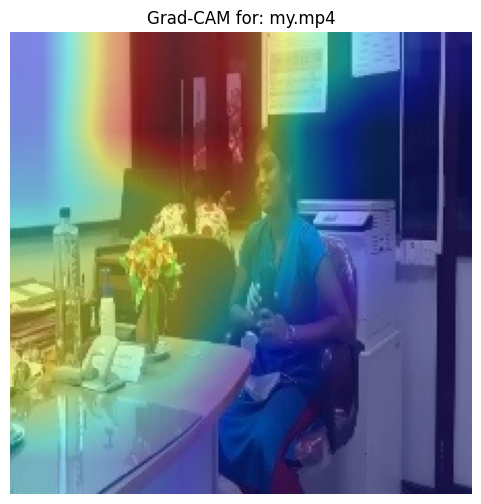

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os



if 'external_gradcam_path' in locals() and os.path.exists(external_gradcam_path):
    print("Displaying Grad-CAM for the last processed external video:")
    img = mpimg.imread(external_gradcam_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.title(f'Grad-CAM for: {external_name}.mp4')
    plt.show()
else:
    print("Grad-CAM image not found or not generated for the last processed external video.")
